# SPI current exploration

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [14]:
import os
from pathlib import Path

import geopandas as gpd
import xarray as xr

In [17]:
DATA_DIR = Path(os.getenv("AA_DATA_DIR"))
CPC_GLOBAL_DIR = DATA_DIR / "public" / "raw" / "glb" / "cpc"
CODAB_DIR = DATA_DIR / "public" / "raw" / "bfa" / "cod_ab"

In [19]:
filename = "bfa_cod_ab.shp/bfa_admbnda_adm1_igb_20200323.shp"
codab = gpd.read_file(CODAB_DIR / filename)

<Axes: >

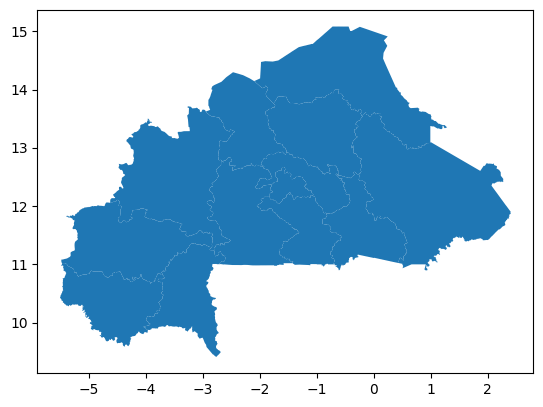

In [20]:
codab.plot()

In [67]:
filename = "GLOBAL-NOAA_CPC_CMORPH-spi-1mo_downloaded_2024-02-28.tif"
da = xr.load_dataarray(CPC_GLOBAL_DIR / filename)
da_clip = da.rio.clip(codab.geometry, all_touched=True)

In [68]:
mask_val = da_clip.isel(y=0, x=20).values[0]

In [69]:
df = da.to_dataframe()

In [70]:
df["band_data"].value_counts().reset_index().sort_values("band_data")

,band_data,count
0,-1.902639e+00,89210
22,-1.465516e+00,20730
21,-1.204172e+00,22132
20,-1.006244e+00,22575
19,-8.414567e-01,23584
18,-6.968582e-01,24062
16,-5.655735e-01,24592
17,-4.434294e-01,24481
13,-3.276308e-01,25287
12,-2.161462e-01,25411


In [71]:
df_clip = da_clip.to_dataframe()

In [72]:
df_clip["band_data"].value_counts()

band_data
-1.902639    317
 1.902639     42
 1.204172     18
 1.465516     17
 1.006244     11
 0.565574      7
 0.841457      4
 0.696858      4
 0.327631      4
 0.443429      3
 0.107384      3
-0.841457      1
 0.216146      1
Name: count, dtype: int64

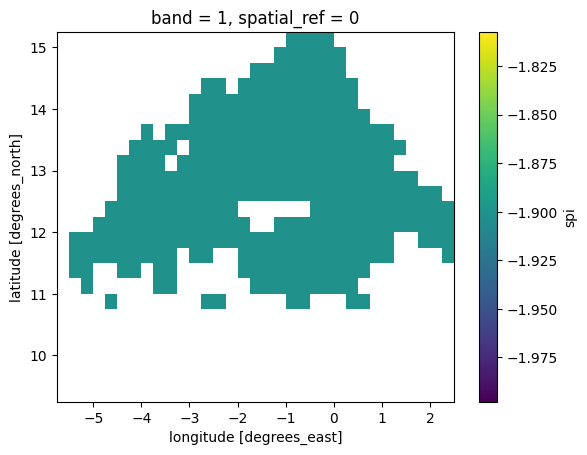

In [73]:
da_clip.where(da_clip == mask_val).plot()

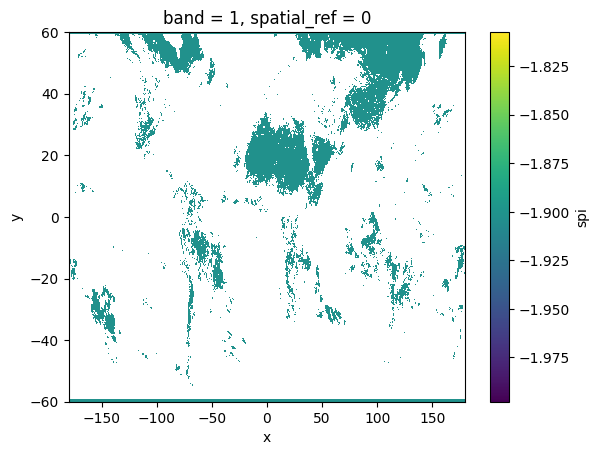

In [74]:
da.where(da == mask_val).plot()